In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import pickle
import math

from sklearn.preprocessing import LabelEncoder

%matplotlib inline
pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Import the dataset from a CSV file
data = pd.read_csv(r'..\..\Datasets\Car Price Prediction.csv')
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


---
## ***EDA Report***

In [3]:
# Create a data report and save it as an HTML file
profile = ProfileReport(data, title="My Data Report", explorative=True)
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 18/18 [00:00<00:00, 135.44it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [5]:
# describe numerical columns
data.select_dtypes(include = 'number').describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [6]:
# describe categorical columns
data.select_dtypes(include = 'object').describe()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237,19237
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5819,3769,1083,8736,13954,10150,3916,721,13514,12874,18332,17753,5033


---
## ***Preprocessing***

In [7]:
# Check for missing values in the dataset
data.isnull().sum()

ID                  0
Price               0
Levy                0
Manufacturer        0
Model               0
Prod. year          0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Cylinders           0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
Airbags             0
dtype: int64

In [8]:
# Check for duplicated rows values in the dataset
data.duplicated().sum()
data.drop_duplicates(inplace = True)

In [9]:
data.drop('ID', inplace=True, axis = 1)

data['Levy'] = data['Levy'].replace('-', 0)
data['Levy'] = pd.to_numeric(data['Levy'])

data['Leather interior'] = data['Leather interior'].replace({'Yes' : 1, 'No' : 0})
data['Leather interior'] = pd.to_numeric(data['Leather interior'])

data['Engine volume'] = data['Engine volume'].str.replace('Turbo', '')
data['Engine volume'] = pd.to_numeric(data['Engine volume'])

data['Mileage'] = data['Mileage'].str.replace('km', '')
data['Mileage'] = pd.to_numeric(data['Mileage'])

data['Doors'] = data['Doors'].replace({'04-May' : 4, '02-Mar' : 2, '>5' : 6})
data['Doors'] = pd.to_numeric(data['Doors'])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  int64  
 2   Manufacturer      18924 non-null  object 
 3   Model             18924 non-null  object 
 4   Prod. year        18924 non-null  int64  
 5   Category          18924 non-null  object 
 6   Leather interior  18924 non-null  int64  
 7   Fuel type         18924 non-null  object 
 8   Engine volume     18924 non-null  float64
 9   Mileage           18924 non-null  int64  
 10  Cylinders         18924 non-null  float64
 11  Gear box type     18924 non-null  object 
 12  Drive wheels      18924 non-null  object 
 13  Doors             18924 non-null  int64  
 14  Wheel             18924 non-null  object 
 15  Color             18924 non-null  object 
 16  Airbags           18924 non-null  int64  
dty

In [11]:
one_hot_columns = ["Gear box type", "Drive wheels", "Wheel"]
data = pd.get_dummies(data, columns = one_hot_columns)
one_hot_encoded_columns = [col for col in data.columns if col.startswith(('Gear box type', 'Drive wheels', 'Wheel'))]
data[one_hot_encoded_columns] = data[one_hot_encoded_columns].astype(int)

label_encode_columns = ['Manufacturer', 'Category', 'Color', 'Fuel type', 'Model']
label_encoder = LabelEncoder()

for col in label_encode_columns:
    data[col] = label_encoder.fit_transform(data[col])

In [12]:
numerical_features = data.select_dtypes(include = 'number').columns
categorical_features = data.select_dtypes(include = 'object').columns

# discrete features
discrete_features = [feature for feature in data if len(data[feature].unique()) <= 17]

# Continuous features
continuous_features = [feature for feature in data if feature not in discrete_features]

print('Number of Numerical features: ', len(numerical_features))
print('Number of categorical features: ', len(categorical_features))
print('Number of discrete features: ', len(discrete_features))
print('Number of continuous features: ', len(continuous_features))


Number of Numerical features:  23
Number of categorical features:  0
Number of discrete features:  16
Number of continuous features:  7


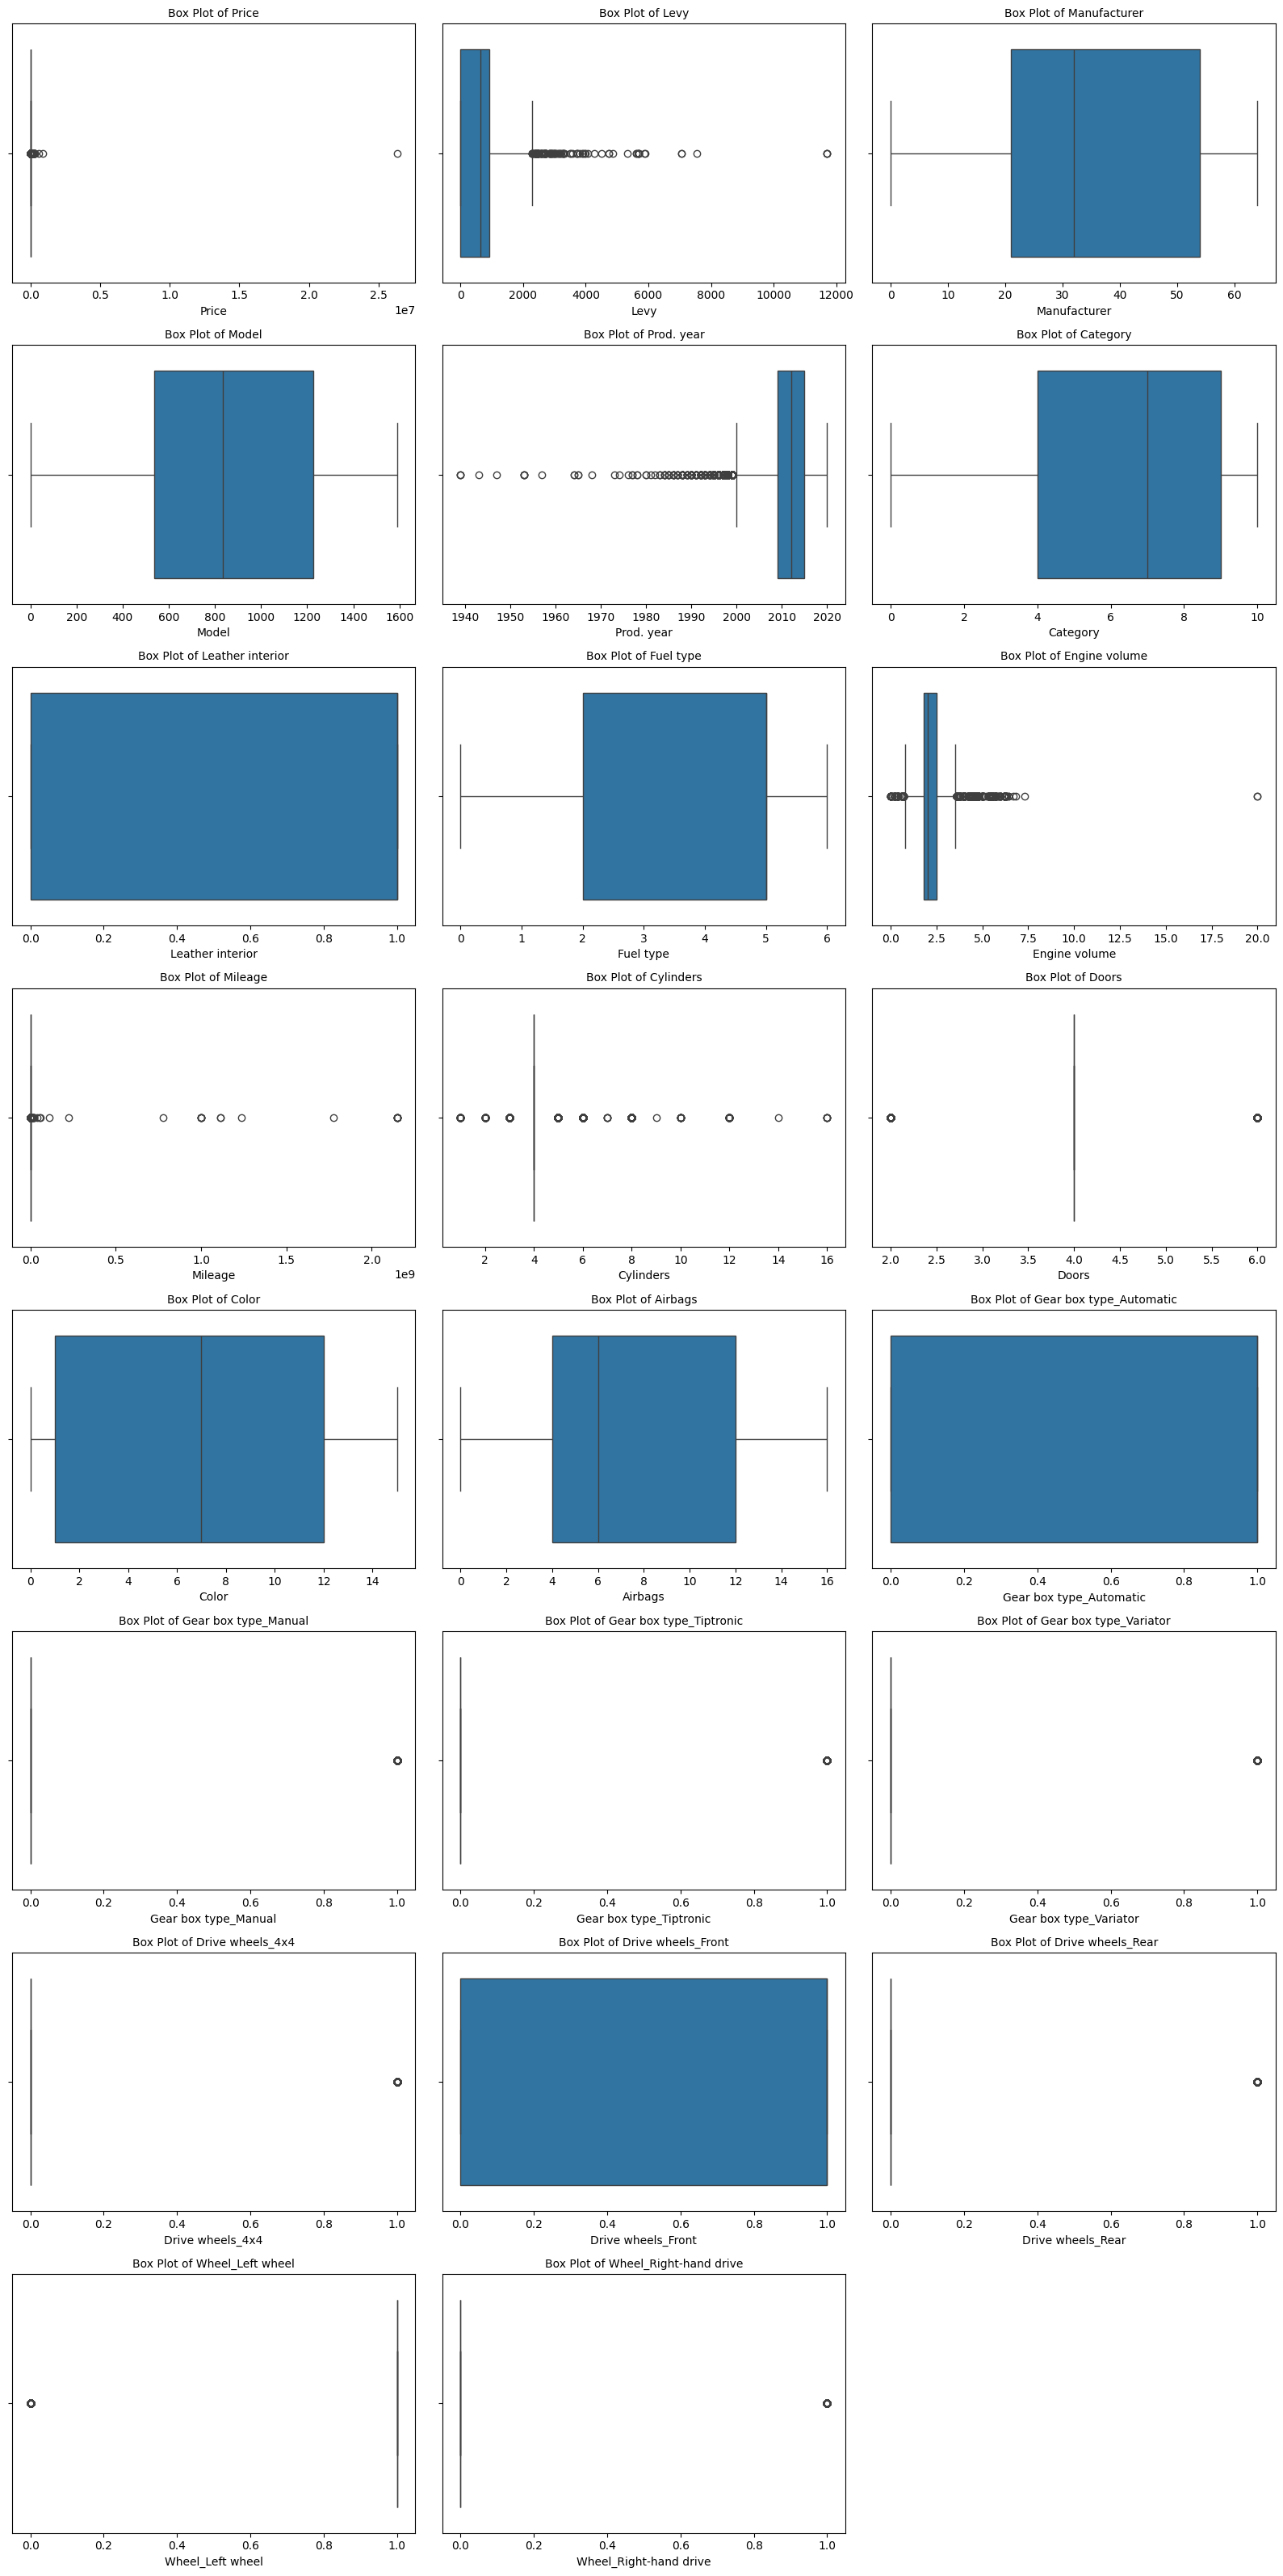

In [13]:
def plot_multiple_boxplots(data, features, cols=3):
    total = len(features)
    rows = math.ceil(total / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    axes = axes.flatten()  # Flatten for easy indexing

    for i, feature in enumerate(features):
        sns.boxplot(data=data, x=feature, ax=axes[i])
        axes[i].set_title(f'Box Plot of {feature}', fontsize=10)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_multiple_boxplots(data, numerical_features)

In [14]:
def handle_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        upper_bound = Q3 + 1.5 * IQR
        lower_bound = Q1 - 1.5 * IQR

        # Trimming Outliers
        # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

        # Capping Outliers
        df.loc[df[col] > upper_bound, col] = upper_bound
        df.loc[df[col] < lower_bound, col] = lower_bound
    
    return df

# Apply outlier handling to the Price and other numerical columns
handle_outliers(data, numerical_features)

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Doors,Color,Airbags,Gear box type_Automatic,Gear box type_Manual,Gear box type_Tiptronic,Gear box type_Variator,Drive wheels_4x4,Drive wheels_Front,Drive wheels_Rear,Wheel_Left wheel,Wheel_Right-hand drive
0,13328,1399.0,32.0,1242.0,2010,4.0,1.0,2.0,3.5,186005.0,4.0,4,12.0,12,1.0,0,0,0,0,0.0,0,1,0
1,16621,1018.0,8.0,658.0,2011,4.0,0.0,5.0,3.0,192000.0,4.0,4,1.0,8,0.0,0,0,0,0,0.0,0,1,0
2,8467,0.0,21.0,684.0,2006,3.0,0.0,5.0,1.3,200000.0,4.0,4,1.0,2,0.0,0,0,0,0,1.0,0,1,0
3,3607,862.0,16.0,661.0,2011,4.0,1.0,2.0,2.5,168966.0,4.0,4,14.0,0,1.0,0,0,0,0,0.0,0,1,0
4,11726,446.0,21.0,684.0,2014,3.0,1.0,5.0,1.3,91901.0,4.0,4,12.0,4,1.0,0,0,0,0,1.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,8467,0.0,36.0,385.0,2000,1.0,1.0,0.0,2.0,300000.0,4.0,4,12.0,5,0.0,0,0,0,0,0.0,0,1,0
19233,15681,831.0,23.0,1334.0,2011,9.0,1.0,5.0,2.4,161600.0,4.0,4,11.0,8,0.0,0,0,0,0,1.0,0,1,0
19234,26108,836.0,23.0,1442.0,2010,4.0,1.0,1.0,2.0,116365.0,4.0,4,7.0,4,1.0,0,0,0,0,1.0,0,1,0
19235,5331,1288.0,8.0,456.0,2007,4.0,1.0,1.0,2.0,51258.0,4.0,4,1.0,4,1.0,0,0,0,0,1.0,0,1,0


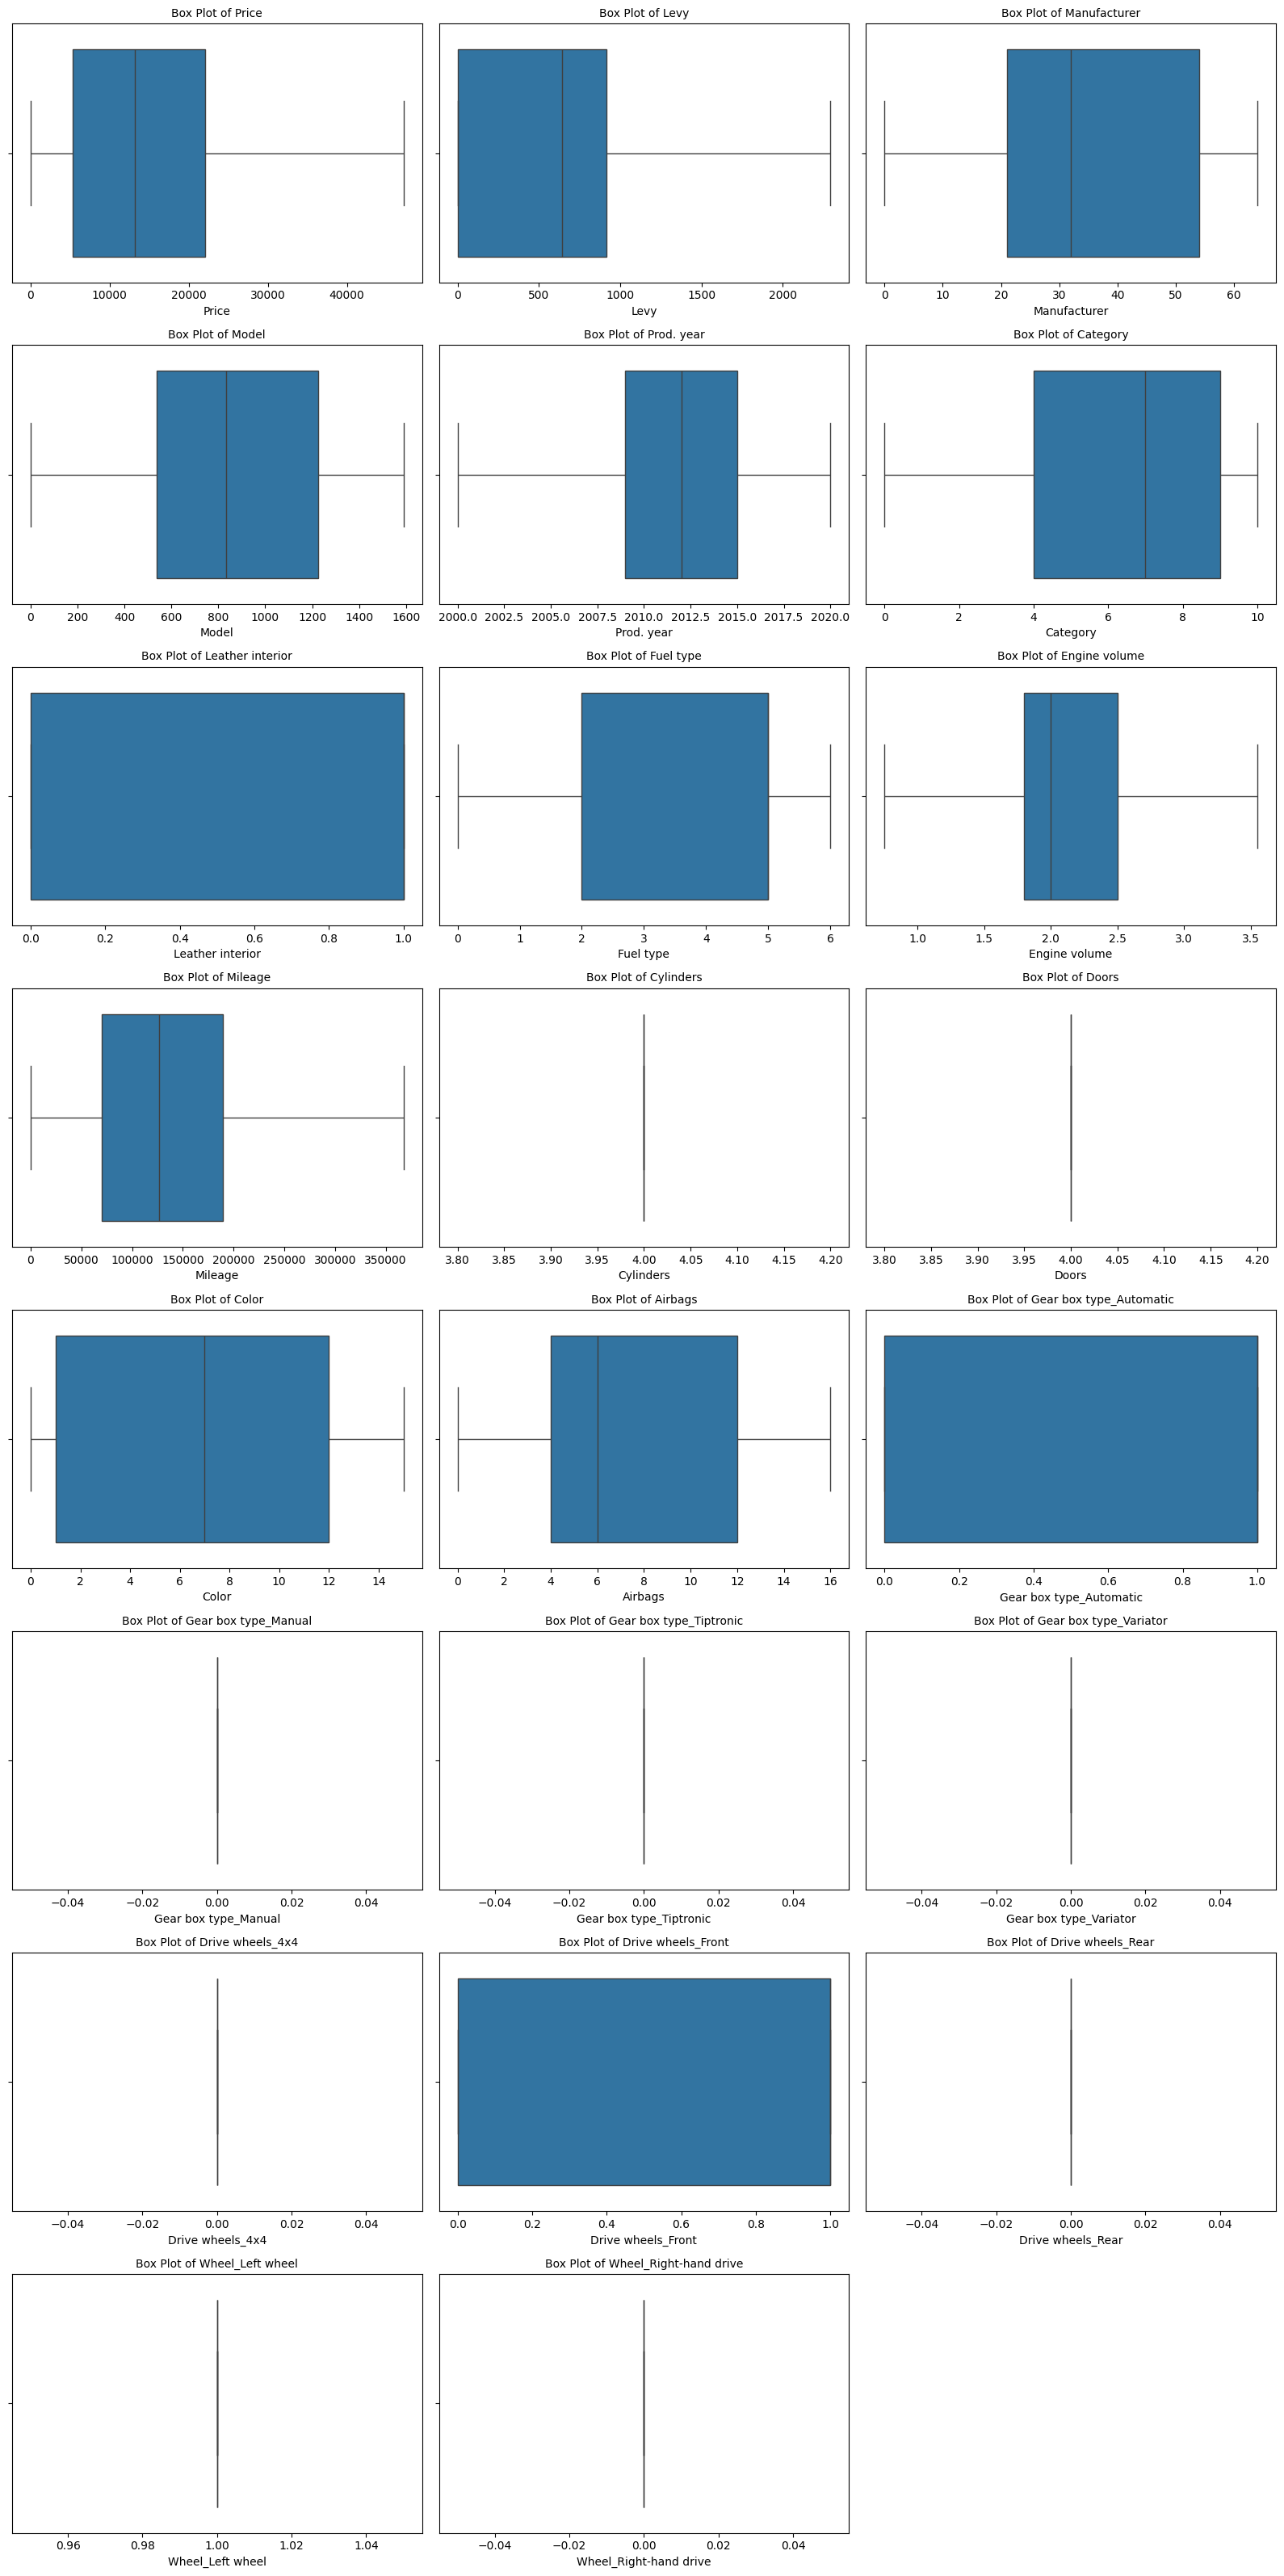

In [15]:
# Box Plot For each Numerical Feature After Handling Outliers
plot_multiple_boxplots(data, numerical_features)

---
## ***Visualization***

<Figure size 1000x600 with 0 Axes>

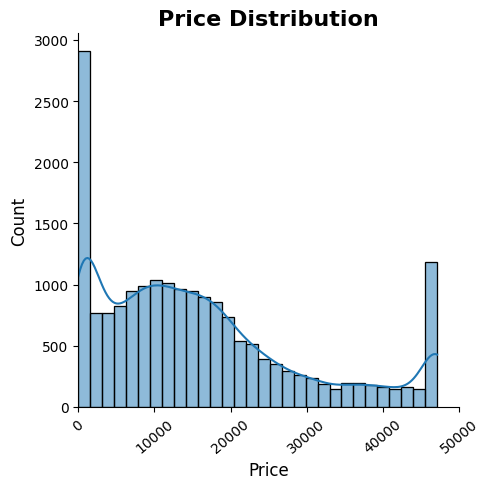

In [16]:
# Price Distribution
plt.figure(figsize = (10, 6))

sns.displot(data["Price"], bins = 30, kde = True, edgecolor = 'black')

plt.title('Price Distribution', fontsize = 16, fontweight = 'bold')
plt.xlabel('Price', fontsize = 12)
plt.ylabel('Count', fontsize = 12);

plt.xticks(rotation = 40);
plt.xlim([0, 50000])

plt.tight_layout()
plt.show()

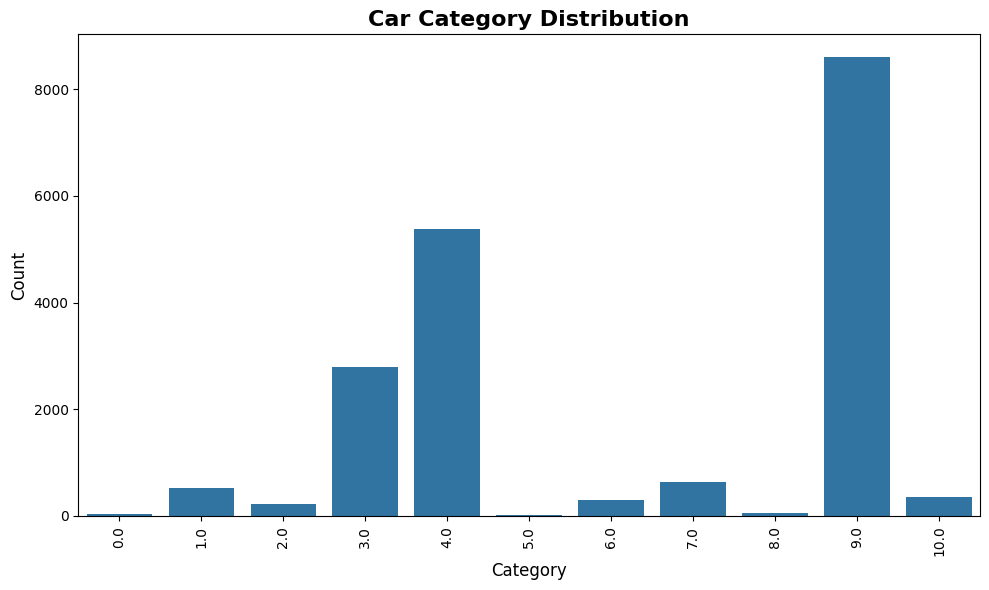

In [17]:
# Car Category Distribution
plt.figure(figsize=(10, 6))

sns.countplot(x='Category', data=data)

plt.title('Car Category Distribution', fontsize = 16, fontweight = 'bold')
plt.xlabel('Category', fontsize = 12)
plt.ylabel('Count', fontsize = 12)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

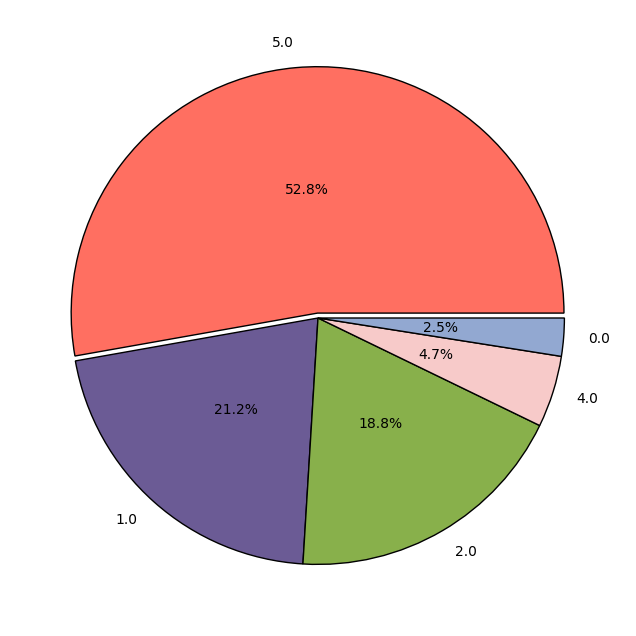

In [18]:
# Fuel Type Distribution
fuel_control = data['Fuel type'].value_counts().reset_index()
fuel_control.drop(index = [5, 6], axis = 0, inplace = True)
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1']
explode = [0.02, 0, 0, 0, 0]

plt.figure(figsize = (8, 8));

plt.pie(fuel_control['count'],
        labels = fuel_control['Fuel type'],
        explode = explode,
        colors = colors,
        autopct = '%1.1f%%',
        pctdistance=0.5,
        wedgeprops = {'edgecolor': 'black', 'antialiased': True},  # 'wedgeprops': Properties for the wedges, here we set the edge color to black
        textprops = {'fontsize': 10, 'color': 'black'});

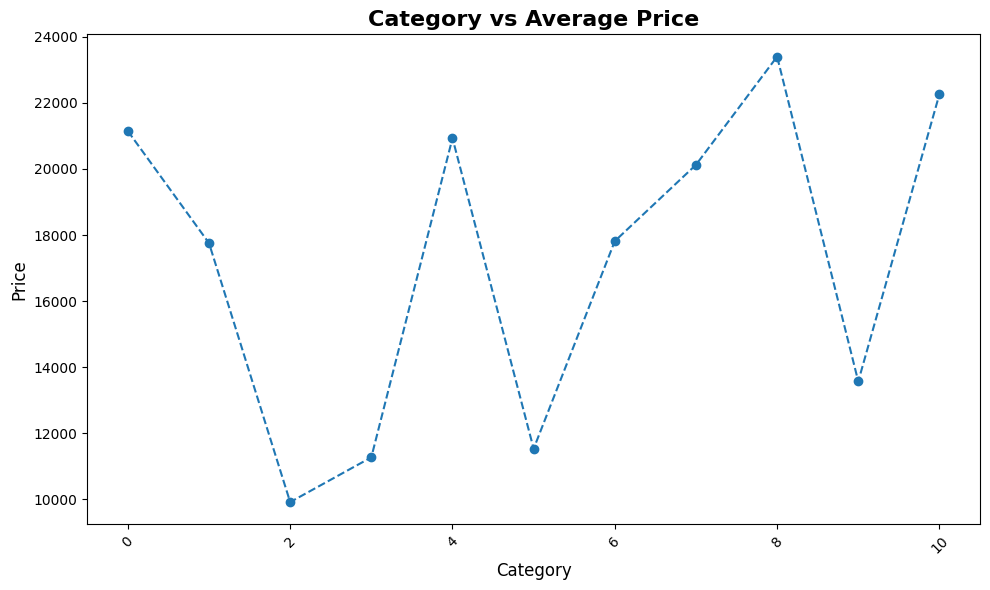

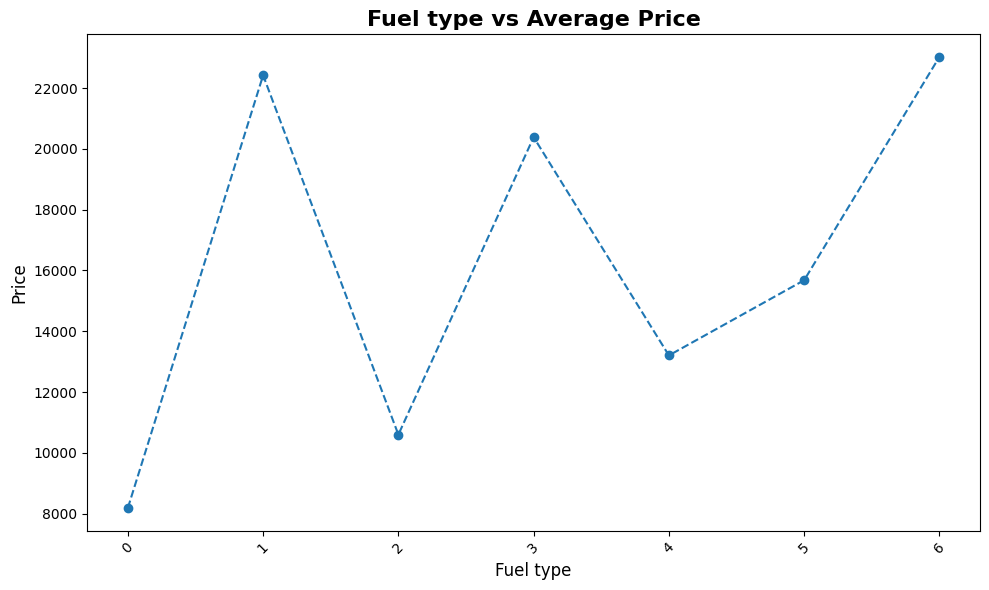

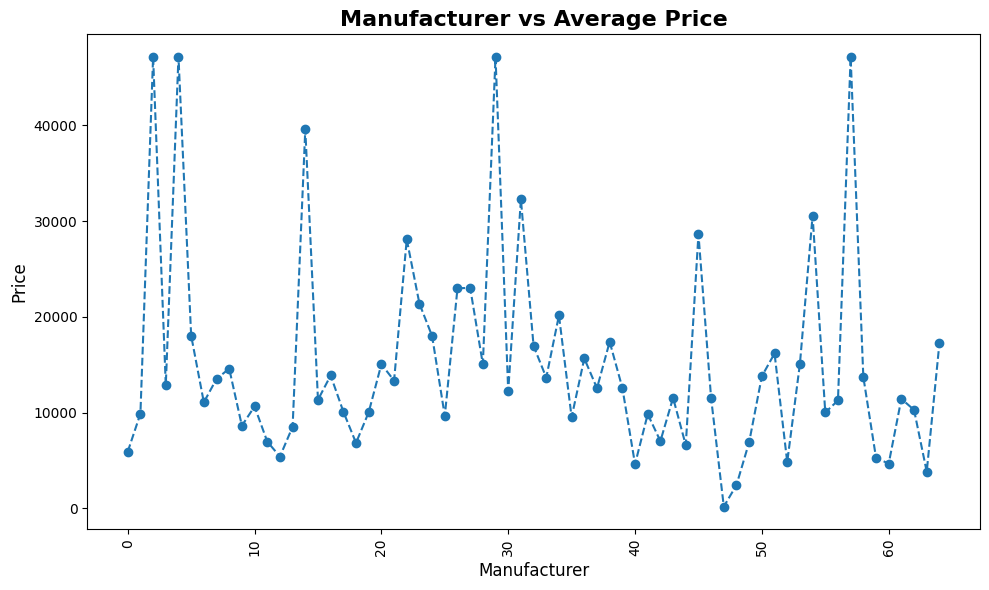

In [19]:
# Price vs Some Features
x_axis_columns = ['Category', 'Fuel type', 'Manufacturer']

for i, x_axis_column in enumerate(x_axis_columns):

    fig, ax = plt.subplots(figsize = (10, 6))
    x_avg_price = data.groupby(x_axis_column)['Price'].mean().reset_index()

    ax.plot(x_avg_price[x_axis_column], x_avg_price['Price'], linestyle = '--', marker = 'o')
    ax.set_title(f'{x_axis_column} vs Average Price', fontsize = 16, fontweight = 'bold')
    ax.set_xlabel(f'{x_axis_column}', fontsize = 12)
    ax.set_ylabel('Price', fontsize = 12)
    ax.tick_params(axis = 'x', rotation = 45)

    if x_axis_column == 'Manufacturer':
        ax.tick_params(axis = 'x', rotation = 90)

    plt.tight_layout()
    plt.show()

---
## ***Saving Preprocessed Data with Pickle***

In [20]:
# Save the preprocessed data to a Pickle file
with open('Pickled Objects/preprocessed_data.pkl', 'wb') as file:
    pickle.dump(data, file)